# Kenya Economic Indicators Analysis (2000-2023)
**Data Source:** World Bank Open Data  
**Analyst:** Euniter Kwamboka Bosire  
**Date:** July 2026

## Overview
This notebook analiyses Kenya's key economic indicators over 23 years including 
GDP growth rate, GDP per capita, unemployment rate and poverty headcount ratio.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Loading the Data
The dataset was compiled from World Bank Open Data and saved as a CSV file 
covering Kenya's economic indicators from 2000 to 2023.

In [7]:
df = pd.read_csv("kenya_Economic_Data.csv")
print(df.head())
print(f"\nDataset shape: {df.shape}")

   Year  GDP_Growth_%  GDP_PerCapita_USD  Poverty_Rate_%  Unemployment_%
0  2000      0.599695         414.626365             NaN           2.884
1  2001      3.779906         410.700452             NaN           2.876
2  2002      0.546860         402.936386             NaN           2.916
3  2003      2.932476         442.898457             NaN           2.869
4  2004      5.104300         463.662781             NaN           2.844

Dataset shape: (24, 5)


In [8]:
# Display full dataset
df

,Year,GDP_Growth_%,GDP_PerCapita_USD,Poverty_Rate_%,Unemployment_%
0,2000,0.599695,414.626365,NaN,2.884
1,2001,3.779906,410.700452,NaN,2.876
2,2002,0.546860,402.936386,NaN,2.916
3,2003,2.932476,442.898457,NaN,2.869
4,2004,5.104300,463.662781,NaN,2.844
5,2005,5.906666,523.456312,44.6,2.739
6,2006,6.472494,699.802371,NaN,2.673
7,2007,6.850730,840.201439,NaN,2.642
8,2008,0.232283,915.544355,NaN,2.751
9,2009,3.306940,1047.967832,NaN,2.816


## Data Exploration
Before visualising,we check the structure and summary statistics of the dataset.

In [10]:
print("Dataset Info")
print(df.info())
print(df.describe().round(2))

Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               24 non-null     int64  
 1   GDP_Growth_%       24 non-null     float64
 2   GDP_PerCapita_USD  24 non-null     float64
 3   Poverty_Rate_%     5 non-null      float64
 4   Unemployment_%     24 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 1.1 KB
None
          Year  GDP_Growth_%  GDP_PerCapita_USD  Poverty_Rate_%  \
count    24.00         24.00              24.00            5.00   
mean   2011.50          4.33            1209.87           43.72   
std       7.07          2.23             594.52            3.46   
min    2000.00         -0.27             402.94           37.70   
25%    2005.75          3.66             655.72           44.40   
50%    2011.50          4.91            1190.58           44.60   
75%    2017.25          5.67        

### Correlation Between Indicators
Examining how Kenya's economic indicators relate to each other.

In [12]:
print("Correlation between indicators:")
df[['GDP_Growth_%', 'GDP_PerCapita_USD', 'Unemployment_%']].corr().round(2)

Correlation between indicators:


,GDP_Growth_%,GDP_PerCapita_USD,Unemployment_%
GDP_Growth_%,1.00,0.23,0.06
GDP_PerCapita_USD,0.23,1.00,0.76
Unemployment_%,0.06,0.76,1.00


### Average Indicators by Decade

In [13]:
df['Decade'] = pd.cut(df['Year'], bins=[1999, 2009, 2019, 2023], 
                       labels=['2000s', '2010s', '2020s'])
df.groupby('Decade', observed=True)[['GDP_Growth_%', 'Unemployment_%']].mean().round(2)

,GDP_Growth_%,Unemployment_%
Decade,,
2000s,3.57,2.80
2010s,5.03,3.21
2020s,4.47,5.57


## Data Visualisation
The following charts explore trends in Kenya's economic indicators from 2000 to 2023.

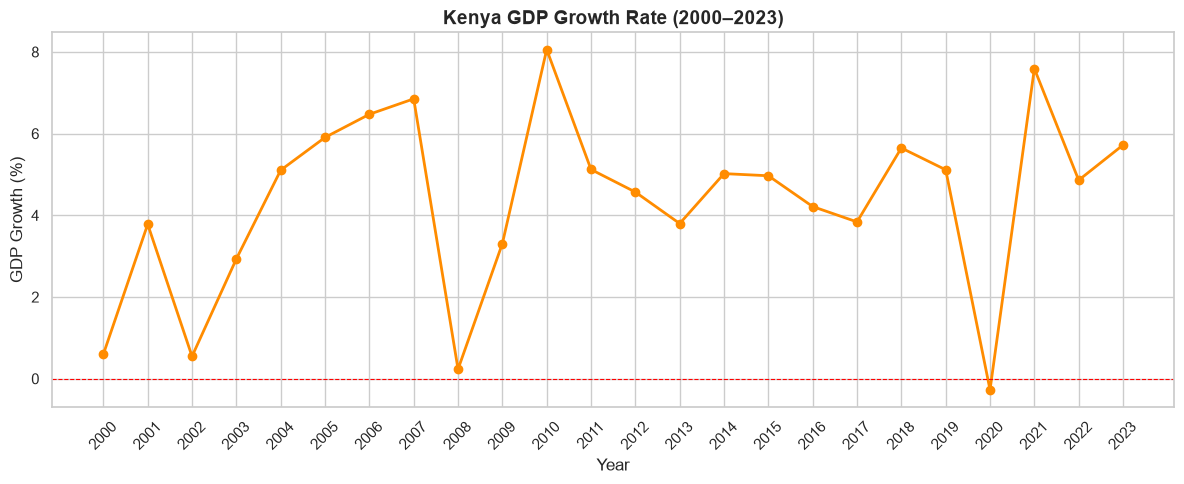

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(df['Year'], df['GDP_Growth_%'], marker='o', color='darkorange', linewidth=2)
plt.title("Kenya GDP Growth Rate (2000–2023)", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.xticks(df['Year'], rotation=45)
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

### GDP Per Capita Trend
Kenya's income per person grew nearly 5x over the study period, 
reflecting sustained economic development.

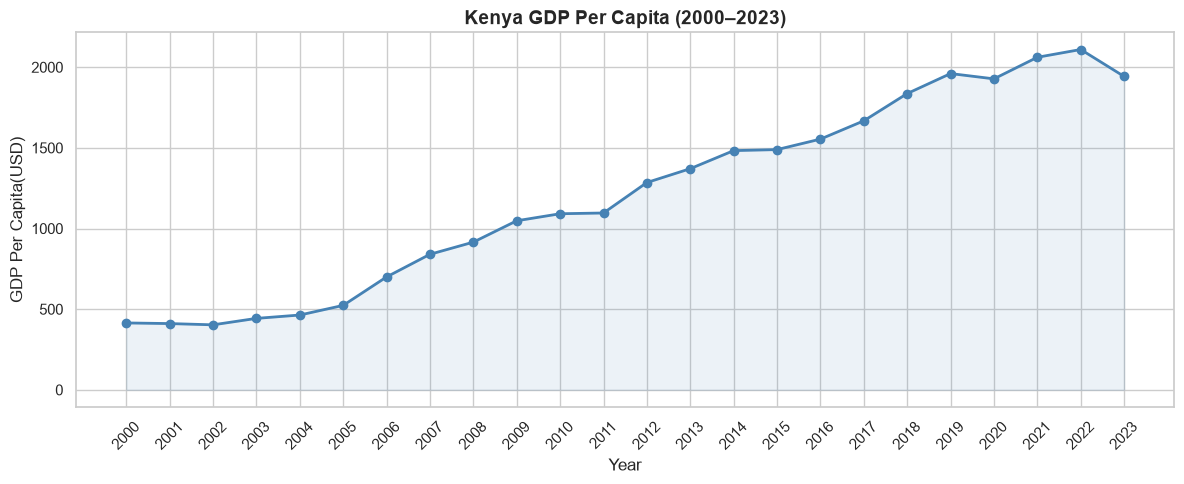

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(df['Year'], df['GDP_PerCapita_USD'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(df['Year'], df['GDP_PerCapita_USD'], alpha=0.1, color='steelblue')
plt.title("Kenya GDP Per Capita (2000–2023)", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("GDP Per Capita(USD)")
plt.xticks(df['Year'], rotation=45)
plt.tight_layout()
plt.show()

### Unemployment Rate Trend
Unemployment remained stable for nearly two decades before rising 
sharply from 2017, with COVID-19 accelerating the increase in 2020–2021.

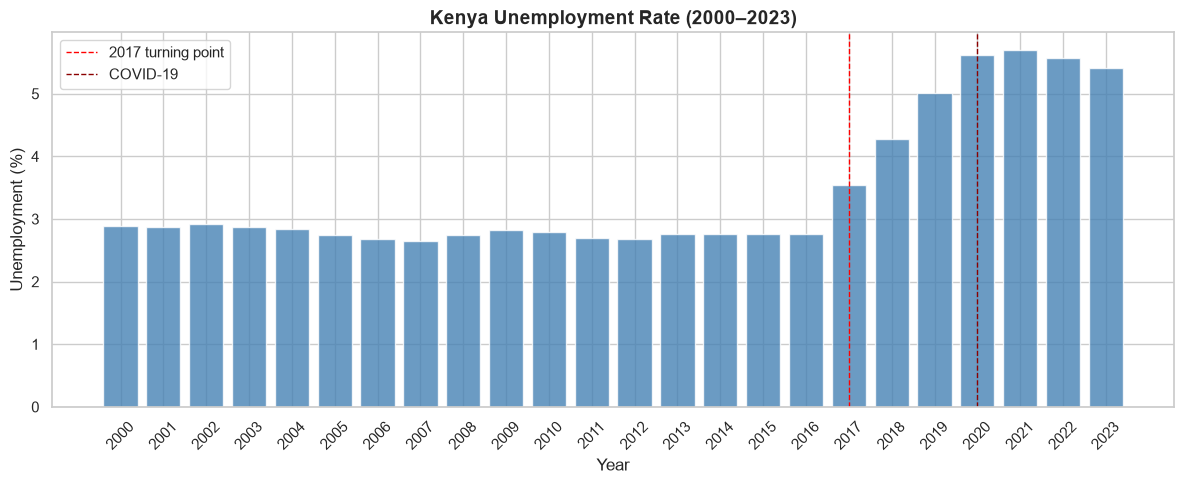

In [17]:
plt.figure(figsize=(12, 5))
plt.bar(df['Year'], df['Unemployment_%'], color='steelblue', alpha=0.8)
plt.title("Kenya Unemployment Rate (2000–2023)", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Unemployment (%)")
plt.xticks(df['Year'], rotation=45)
plt.axvline(x=2017, color='red', linestyle='--', linewidth=1, label='2017 turning point')
plt.axvline(x=2020, color='darkred', linestyle='--', linewidth=1, label='COVID-19')
plt.legend()
plt.tight_layout()
plt.show()

### Poverty Rate Trend
Poverty data is only available for select survey years. Despite a decline 
between 2005 and 2015, COVID-19 reversed the gains pushing the rate back up.

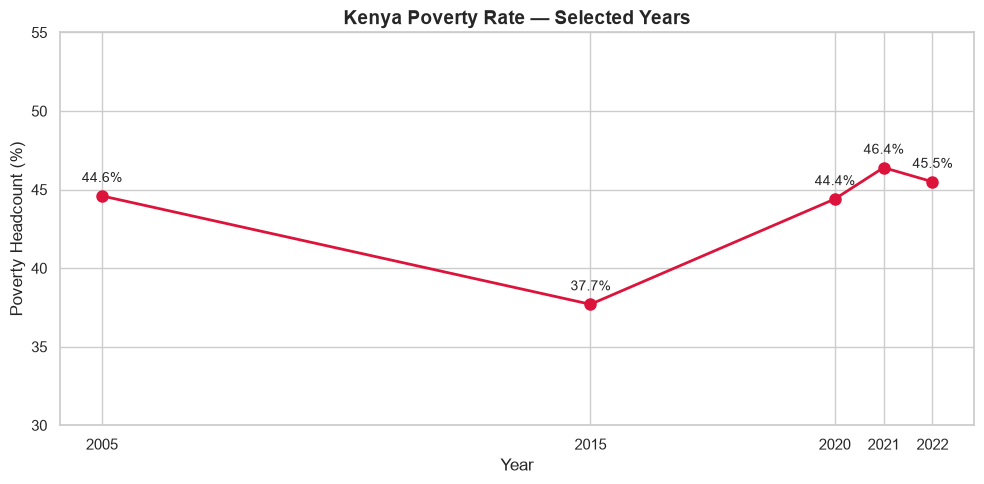

In [13]:
poverty_df = df.dropna(subset=['Poverty_Rate_%'])

plt.figure(figsize=(10, 5))
plt.plot(poverty_df['Year'], poverty_df['Poverty_Rate_%'], 
         marker='o', color='crimson', linewidth=2, markersize=8)
plt.title("Kenya Poverty Rate — Selected Years", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Poverty Headcount (%)")
plt.xticks(poverty_df['Year'])
plt.ylim(30, 55)
for x, y in zip(poverty_df['Year'], poverty_df['Poverty_Rate_%']):
    plt.annotate(f'{y}%', (x, y), textcoords="offset points", 
                 xytext=(0, 10), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## Key Findings

- Kenya sustained an average GDP growth rate of **4.33%** for a period of 23 years
- Best year was **2010** with **8.06%** growth rate due to post-crisis recovery
- **2020 was the only year with negative growth rate of -0.27%** due to COVID-19
- Unemployment rate was stable around **2.7%** for 17 years until it peaked at **5.69%** in 2021
- GDP Per Capita and Unemployment had a strong positive correlation of **0.76**, 
suggesting economic growth did not translate into job creation for all Kenyans
- Despite the poverty rate decrease from **44.6% in 2005 to 37.7% in 2015**, COVID-19 setback the progress and increased the rate to **46.4%** in 2021
- GDP per capita grew from **$414** in 2000 to **$1,943** in 2023, nearly a fivefold increase

## Conclusion

Kenya's economic data tells a story of real progress interrupted by global shocks. 
Despite notable increases in GDP and income, about half of the population still lives 
below the poverty line, and unemployment is on the rise.

*Data Source: World Bank Open Data | Data cleaned and explored in Microsoft Excel | 
Further analysis and visualisation in Python | Analysis by Euniter Kwamboka Bosire | July 2026*